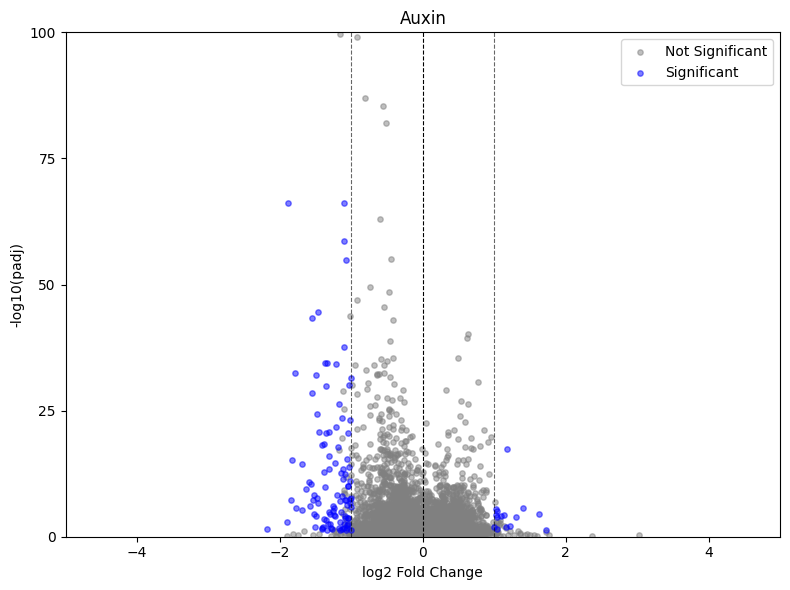

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------
# Load DESeq2 results
# ------------------------------
auxin = pd.read_csv(
    r"C:\Users\tkx1376\OneDrive - Northwestern University\RNA Sequencing\HP1a\rsem\DESeq2_Auxin_vs_Control.csv",
    index_col=0
)

# ---------- AUXIN ----------
log2fc = combined["Auxin_log2FC"]
padj   = combined["Auxin_padj"].replace(0, np.nan)
neglog10 = -np.log10(padj)

# -----------------------------
# SIGNIFICANCE RULES
# -----------------------------
fc_sig = abs(log2fc) >= 1         # FC cutoff
padj_sig = padj < 0.05            # p-adj cutoff
sig_mask = fc_sig & padj_sig
nonsig_mask = ~sig_mask

# Optional jitter to visually separate gray points
jitter_amount = 0.15
log2fc_jittered = log2fc[nonsig_mask] + np.random.normal(
    0, jitter_amount, sum(nonsig_mask)
)

plt.figure(figsize=(8,6))

# Non-significant = gray
plt.scatter(
    log2fc_jittered, neglog10[nonsig_mask],
    s=15, color="gray", alpha=0.5,
    label="Not Significant"
)

# Significant = blue
plt.scatter(
    log2fc[sig_mask], neglog10[sig_mask],
    s=15, color="blue", alpha=0.5,
    label="Significant"
)

# Threshold lines
plt.axvline(-1, linestyle="--", color="black", linewidth=0.8, alpha=0.6)
plt.axvline(1,  linestyle="--", color="black", linewidth=0.8, alpha=0.6)
plt.axvline(0,  linestyle="--", color="black", linewidth=0.8)

# -----------------------------
# Y-AXIS: 0, 25, 50, 75, 100
# -----------------------------
plt.ylim([0, 100])
plt.yticks([0, 25, 50, 75, 100])
plt.gca().ticklabel_format(style='plain', axis='y')  # remove scientific notation

plt.xlim([-5, 5])

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(padj)")
plt.title("Auxin")
plt.legend()

plt.tight_layout()
plt.show()


 AUXIN SIGNIFICANT GENE COUNTS
 Upregulated (log2FC ≥ 1):   15
 Downregulated (log2FC ≤ -1): 103
 Total significant:            118



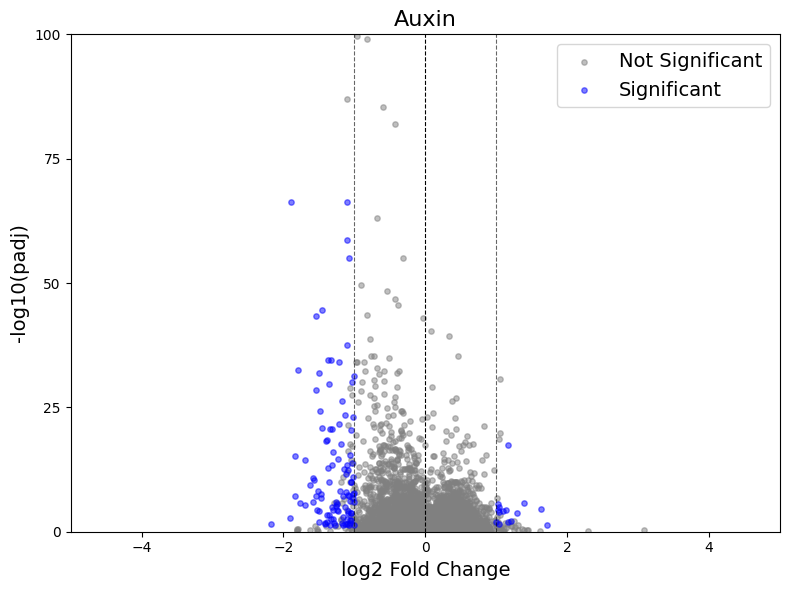

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------
# Load DESeq2 results
# ------------------------------
auxin = pd.read_csv(
    r"C:\Users\tkx1376\OneDrive - Northwestern University\RNA Sequencing\HP1a\rsem\DESeq2_Auxin_vs_Control.csv",
    index_col=0
)

# ---------- AUXIN ----------
log2fc = combined["Auxin_log2FC"]
padj   = combined["Auxin_padj"].replace(0, np.nan)
neglog10 = -np.log10(padj)

# -----------------------------
# SIGNIFICANCE RULES
# -----------------------------
fc_sig = abs(log2fc) >= 1         # FC cutoff
padj_sig = padj < 0.05            # p-adj cutoff
sig_mask = fc_sig & padj_sig
nonsig_mask = ~sig_mask

# ===============================
# Count upregulated vs downregulated genes
# ===============================

up_mask = (log2fc >= 1) & (padj < 0.05)
down_mask = (log2fc <= -1) & (padj < 0.05)

num_up = np.sum(up_mask)
num_down = np.sum(down_mask)

print("================================")
print(" AUXIN SIGNIFICANT GENE COUNTS")
print("================================")
print(f" Upregulated (log2FC ≥ 1):   {num_up}")
print(f" Downregulated (log2FC ≤ -1): {num_down}")
print(f" Total significant:            {num_up + num_down}")
print("================================\n")

# Optional jitter to visually separate gray points
jitter_amount = 0.15
log2fc_jittered = log2fc[nonsig_mask] + np.random.normal(
    0, jitter_amount, sum(nonsig_mask)
)

plt.figure(figsize=(8,6))

# Non-significant = gray
plt.scatter(
    log2fc_jittered, neglog10[nonsig_mask],
    s=15, color="gray", alpha=0.5,
    label="Not Significant"
)

# Significant = blue
plt.scatter(
    log2fc[sig_mask], neglog10[sig_mask],
    s=15, color="blue", alpha=0.5,
    label="Significant"
)

# Threshold lines
plt.axvline(-1, linestyle="--", color="black", linewidth=0.8, alpha=0.6)
plt.axvline(1,  linestyle="--", color="black", linewidth=0.8, alpha=0.6)
plt.axvline(0,  linestyle="--", color="black", linewidth=0.8)

# -----------------------------
# Y-AXIS: 0, 25, 50, 75, 100
# -----------------------------
plt.ylim([0, 100])
plt.yticks([0, 25, 50, 75, 100])
plt.gca().ticklabel_format(style='plain', axis='y')  # remove scientific notation

plt.xlim([-5, 5])

plt.xlabel("log2 Fold Change", fontsize=14)
plt.ylabel("-log10(padj)", fontsize=14)
plt.title("Auxin", fontsize=16)
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()


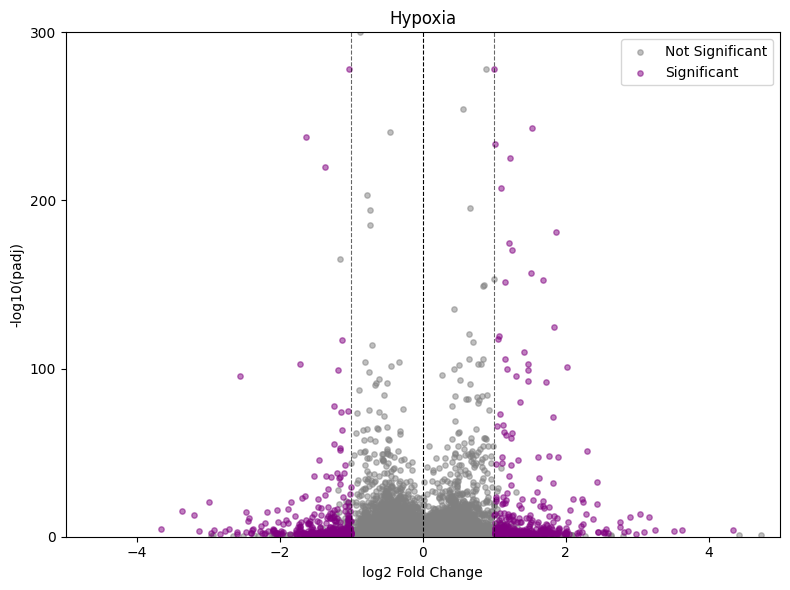

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------
# Load DESeq2 results
# ------------------------------
hypoxia = pd.read_csv(
    r"C:\Users\tkx1376\OneDrive - Northwestern University\RNA Sequencing\HP1a\rsem\DESeq2_Hypoxia_vs_Control.csv",
    index_col=0
)

# ---------- HYPOXIA ----------
log2fc = combined["Hypoxia_log2FC"]
padj   = combined["Hypoxia_padj"].replace(0, np.nan)
neglog10 = -np.log10(padj)

# -----------------------------------------
# SIGNIFICANCE RULES (padj < 0.05 & |log2FC| ≥ 1)
# -----------------------------------------
fc_sig = abs(log2fc) >= 1
padj_sig = padj < 0.05
sig_mask = fc_sig & padj_sig
nonsig_mask = ~sig_mask

# Optional jitter for gray points
jitter_amount = 0.15
log2fc_jittered = log2fc[nonsig_mask] + np.random.normal(
    0, jitter_amount, sum(nonsig_mask)
)

plt.figure(figsize=(8,6))

# Non-significant = gray
plt.scatter(
    log2fc_jittered, neglog10[nonsig_mask],
    s=15, color="gray", alpha=0.5,
    label="Not Significant"
)

# Significant = purple
plt.scatter(
    log2fc[sig_mask], neglog10[sig_mask],
    s=15, color="purple", alpha=0.5,
    label="Significant"
)

# Threshold lines
plt.axvline(-1, linestyle="--", color="black", linewidth=0.8, alpha=0.6)
plt.axvline(1, linestyle="--", color="black", linewidth=0.8, alpha=0.6)
plt.axvline(0, linestyle="--", color="black", linewidth=0.8)

# -------------------------
# Force y-axis increments: 0, 100, 200, 300
# -------------------------
plt.ylim([0, 300])
plt.yticks([0, 100, 200, 300])
plt.gca().ticklabel_format(style='plain', axis='y')  # turn off scientific notation

plt.xlim([-5, 5])

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(padj)")
plt.title("Hypoxia")
plt.legend()

plt.tight_layout()
plt.show()

 HYPOXIA SIGNIFICANT GENE COUNTS
 Upregulated (log2FC ≥ 1):   333
 Downregulated (log2FC ≤ -1): 302
 Total significant:            635



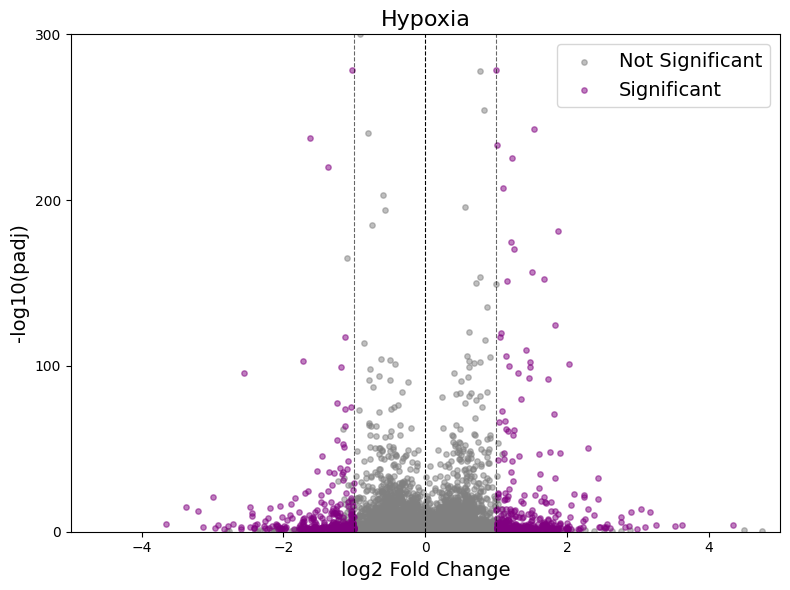

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------
# Load DESeq2 results
# ------------------------------
hypoxia = pd.read_csv(
    r"C:\Users\tkx1376\OneDrive - Northwestern University\RNA Sequencing\HP1a\rsem\DESeq2_Hypoxia_vs_Control.csv",
    index_col=0
)

# ---------- HYPOXIA ----------
log2fc = combined["Hypoxia_log2FC"]
padj   = combined["Hypoxia_padj"].replace(0, np.nan)
neglog10 = -np.log10(padj)

# -----------------------------------------
# SIGNIFICANCE RULES (padj < 0.05 & |log2FC| ≥ 1)
# -----------------------------------------
fc_sig = abs(log2fc) >= 1
padj_sig = padj < 0.05
sig_mask = fc_sig & padj_sig
nonsig_mask = ~sig_mask

# ===============================
# Count upregulated vs downregulated genes
# ===============================

up_mask = (log2fc >= 1) & (padj < 0.05)
down_mask = (log2fc <= -1) & (padj < 0.05)

num_up = np.sum(up_mask)
num_down = np.sum(down_mask)

print("================================")
print(" HYPOXIA SIGNIFICANT GENE COUNTS")
print("================================")
print(f" Upregulated (log2FC ≥ 1):   {num_up}")
print(f" Downregulated (log2FC ≤ -1): {num_down}")
print(f" Total significant:            {num_up + num_down}")
print("================================\n")


# Optional jitter for gray points
jitter_amount = 0.15
log2fc_jittered = log2fc[nonsig_mask] + np.random.normal(
    0, jitter_amount, sum(nonsig_mask)
)

plt.figure(figsize=(8,6))

# Non-significant = gray
plt.scatter(
    log2fc_jittered, neglog10[nonsig_mask],
    s=15, color="gray", alpha=0.5,
    label="Not Significant"
)

# Significant = purple
plt.scatter(
    log2fc[sig_mask], neglog10[sig_mask],
    s=15, color="purple", alpha=0.5,
    label="Significant"
)

# Threshold lines
plt.axvline(-1, linestyle="--", color="black", linewidth=0.8, alpha=0.6)
plt.axvline(1, linestyle="--", color="black", linewidth=0.8, alpha=0.6)
plt.axvline(0, linestyle="--", color="black", linewidth=0.8)

# -------------------------
# Force y-axis increments: 0, 100, 200, 300
# -------------------------
plt.ylim([0, 300])
plt.yticks([0, 100, 200, 300])
plt.gca().ticklabel_format(style='plain', axis='y')  # turn off scientific notation

plt.xlim([-5, 5])

plt.xlabel("log2 Fold Change", fontsize=14)
plt.ylabel("-log10(padj)", fontsize=14)
plt.title("Hypoxia", fontsize=16)
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

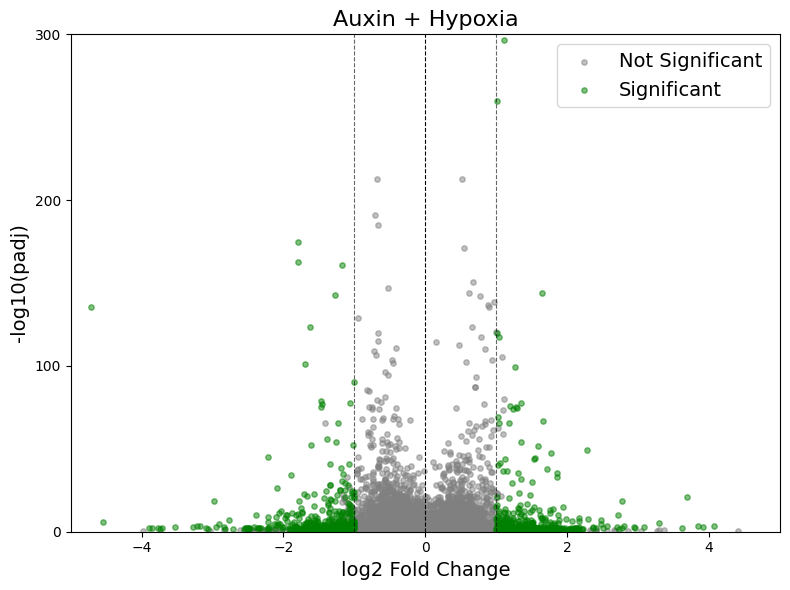

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------
# Load DESeq2 results
# ------------------------------
aux_hyp = pd.read_csv(
    r"C:\Users\tkx1376\OneDrive - Northwestern University\RNA Sequencing\HP1a\rsem\DESeq2_AuxinHypoxia_vs_Control.csv",
    index_col=0
)

# ---------- AUXIN + HYPOXIA ----------
log2fc = combined["Aux+Hyp_log2FC"]
padj   = combined["Aux+Hyp_padj"].replace(0, np.nan)
neglog10 = -np.log10(padj)

# -----------------------------------------
# SIGNIFICANCE RULES (padj < 0.05 & |log2FC| ≥ 1)
# -----------------------------------------
fc_sig = abs(log2fc) >= 1
padj_sig = padj < 0.05
sig_mask = fc_sig & padj_sig
nonsig_mask = ~sig_mask

# Optional jitter for gray points
jitter_amount = 0.15
log2fc_jittered = log2fc[nonsig_mask] + np.random.normal(
    0, jitter_amount, sum(nonsig_mask)
)

plt.figure(figsize=(8,6))

# Non-significant = gray
plt.scatter(
    log2fc_jittered, neglog10[nonsig_mask],
    s=15, color="gray", alpha=0.5,
    label="Not Significant"
)

# Significant = green
plt.scatter(
    log2fc[sig_mask], neglog10[sig_mask],
    s=15, color="green", alpha=0.5,
    label="Significant"
)

# Threshold lines
plt.axvline(-1, linestyle="--", color="black", linewidth=0.8, alpha=0.6)
plt.axvline(1, linestyle="--", color="black", linewidth=0.8, alpha=0.6)
plt.axvline(0, linestyle="--", color="black", linewidth=0.8)

# -------------------------
# Force y-axis increments: 0, 100, 200, 300
# -------------------------
plt.ylim([0, 300])
plt.yticks([0, 100, 200, 300])
plt.gca().ticklabel_format(style='plain', axis='y')  # turn off scientific notation

plt.xlim([-5, 5])

plt.xlabel("log2 Fold Change", fontsize=14)
plt.ylabel("-log10(padj)", fontsize=14)
plt.title("Auxin + Hypoxia", fontsize=16)
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

 AUXIN+HYPOXIA SIGNIFICANT GENE COUNTS
 Upregulated (log2FC ≥ 1):   333
 Downregulated (log2FC ≤ -1): 342
 Total significant:            675



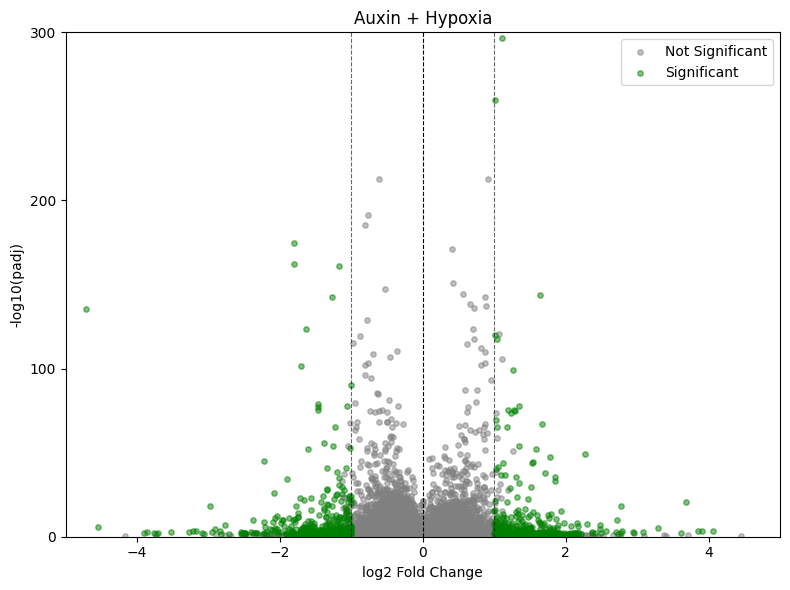

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------
# Load DESeq2 results
# ------------------------------
aux_hyp = pd.read_csv(
    r"C:\Users\tkx1376\OneDrive - Northwestern University\RNA Sequencing\HP1a\rsem\DESeq2_AuxinHypoxia_vs_Control.csv",
    index_col=0
)

# ---------- AUXIN + HYPOXIA ----------
log2fc = combined["Aux+Hyp_log2FC"]
padj   = combined["Aux+Hyp_padj"].replace(0, np.nan)
neglog10 = -np.log10(padj)

# -----------------------------------------
# SIGNIFICANCE RULES (padj < 0.05 & |log2FC| ≥ 1)
# -----------------------------------------
fc_sig = abs(log2fc) >= 1
padj_sig = padj < 0.05
sig_mask = fc_sig & padj_sig
nonsig_mask = ~sig_mask

# ===============================
# Count upregulated vs downregulated genes
# ===============================

up_mask = (log2fc >= 1) & (padj < 0.05)
down_mask = (log2fc <= -1) & (padj < 0.05)

num_up = np.sum(up_mask)
num_down = np.sum(down_mask)

print("================================")
print(" AUXIN+HYPOXIA SIGNIFICANT GENE COUNTS")
print("================================")
print(f" Upregulated (log2FC ≥ 1):   {num_up}")
print(f" Downregulated (log2FC ≤ -1): {num_down}")
print(f" Total significant:            {num_up + num_down}")
print("================================\n")


# Optional jitter for gray points
jitter_amount = 0.15
log2fc_jittered = log2fc[nonsig_mask] + np.random.normal(
    0, jitter_amount, sum(nonsig_mask)
)

plt.figure(figsize=(8,6))

# Non-significant = gray
plt.scatter(
    log2fc_jittered, neglog10[nonsig_mask],
    s=15, color="gray", alpha=0.5,
    label="Not Significant"
)

# Significant = green
plt.scatter(
    log2fc[sig_mask], neglog10[sig_mask],
    s=15, color="green", alpha=0.5,
    label="Significant"
)

# Threshold lines
plt.axvline(-1, linestyle="--", color="black", linewidth=0.8, alpha=0.6)
plt.axvline(1, linestyle="--", color="black", linewidth=0.8, alpha=0.6)
plt.axvline(0, linestyle="--", color="black", linewidth=0.8)

# -------------------------
# Force y-axis increments: 0, 100, 200, 300
# -------------------------
plt.ylim([0, 300])
plt.yticks([0, 100, 200, 300])
plt.gca().ticklabel_format(style='plain', axis='y')  # turn off scientific notation

plt.xlim([-5, 5])

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(padj)")
plt.title("Auxin + Hypoxia")
plt.legend()

plt.tight_layout()
plt.show()